# **Εργασία 1**
Φοιτητής: Ιατρού Κωνσταντίνος 58071

Καθηγητής: Θεωδορακοπουλος Ηλίας

**Άσκηση 2**

Για ένα πρόβλημα ταξινόμησης 2 κλάσεων Ω = {ω1,ω2}, όπου P(x|ω1) = N(2, 0.5) και
P(x|ω2) = N(1.8, 0.2) , με εκ των προτέρων πιθανότητα P(ω1)=1/4 , όπου το κόστος έχει ορισθεί ως λ = [ [0, 1], [3, 0] ].

**Ερώτημα α:** Να βρεθεί η βέλτιστη λύση (κανόνας απόφασης) και να υπολογισθεί το ολικό κόστος.

(Το ολικό κόστος επειδή ζητείται να υπολογιστεί με κώδικα ούτως ή αλλως για το α ερώτημα δεν γράφτηκε κώδικας)

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from math import sqrt
import seaborn as sns

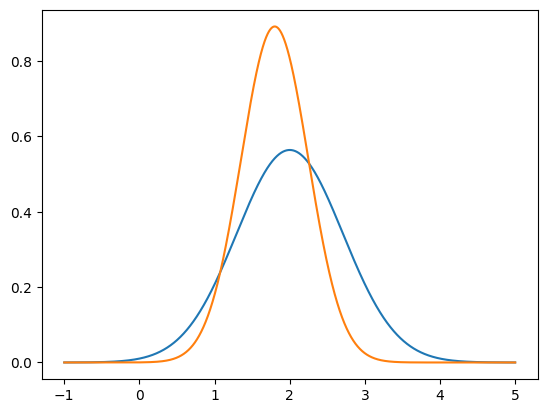

In [119]:
# Μετά απο δοκιμές βρέθηκε ότι για να απεικονιστούν και τα 2 διαγραμματα πιθανότητας το διαστημε που πρέπει να κάνουμε plot είναι μεταξύ -1 και 5
x_axis = np.round(np.arange(-1, 5, 0.001), 3) #Δημιουργώ μία λιστα που θα παίζει τον ρόλο του οριζόντιου άξονα (των x)

px_w1 = norm.pdf(x_axis, 2  , sqrt(0.5))  # p(x|ω1) (Συνάρτηση Πυκνότητας Πιθανότητας)
px_w2 = norm.pdf(x_axis, 1.8, sqrt(0.2))  # p(x|ω2) (Συνάρτηση Πυκνότητας Πιθανότητας)

plt.plot(x_axis, px_w1)
plt.plot(x_axis, px_w2)
plt.show()

In [120]:
priors = [1/4, 1-(1/4)] # Οι a priori πιθανότητες [P(ω1), P(ω2)]
l = [[0, 1], [3, 0]] # Το κόστος

In [121]:
class_w1 = []           # Εδώ θα αποθηκεύονται η τιμές οι οποίες κατηγοριοποιύνται ως κλάση ω1
class_w1_indexes = []   # Εδώ θα αποθηκεύονται τα indexes των τιμών οι οποίες κατηγοριοποιύνται ως κλάση ω1
class_w2 = []           # Εδώ θα αποθηκεύονται η τιμές οι οποίες κατηγοριοποιύνται ως κλάση ω1
class_w2_indexes = []   # Εδώ θα αποθηκεύονται τα indexes των τιμών οι οποίες κατηγοριοποιύνται ως κλάση ω2

for x in range(len(x_axis)):
  R1 = (l[1][0] - l[0][0])* px_w1[x] * priors[0]    #(λ_21-λ_11 )∙p(x│ω_1 )∙P(ω_1) Αν αυτή η τιμή είναι μεγαλύτερη τότε το δείγμα θα κατηγοριοποιείται στην κλάση ω1
  R2 = (l[0][1] - l[1][1])* px_w2[x] * priors[1]    #(λ_12-λ_22 )∙p(x│ω_2 )∙P(ω_2) Αν αυτή η τιμή είναι μεγαλύτερη τότε το δείγμα θα κατηγοριοποιείται στην κλάση ω2

  if R1 > R2 :
    class_w1.append(x_axis[x])          # Κάνω append το δείγμα στην κλάση ω1
    class_w1_indexes.append(x)          # Κάνω append το ιndex του δείγματος στη λίστα με τα ιndexes των δειγμάτων της κλασης ω1
  else :
    class_w2.append(x_axis[x])          # Κάνω append το δείγμα στην κλάση ω2
    class_w2_indexes.append(x)          # Κάνω append το ιndex του δείγματος στη λίστα με τα ιndexes των δειγμάτων της κλασης ω2

print(class_w1)
print(class_w2)

[-1.0, -0.999, -0.998, -0.997, -0.996, -0.995, -0.994, -0.993, -0.992, -0.991, -0.99, -0.989, -0.988, -0.987, -0.986, -0.985, -0.984, -0.983, -0.982, -0.981, -0.98, -0.979, -0.978, -0.977, -0.976, -0.975, -0.974, -0.973, -0.972, -0.971, -0.97, -0.969, -0.968, -0.967, -0.966, -0.965, -0.964, -0.963, -0.962, -0.961, -0.96, -0.959, -0.958, -0.957, -0.956, -0.955, -0.954, -0.953, -0.952, -0.951, -0.95, -0.949, -0.948, -0.947, -0.946, -0.945, -0.944, -0.943, -0.942, -0.941, -0.94, -0.939, -0.938, -0.937, -0.936, -0.935, -0.934, -0.933, -0.932, -0.931, -0.93, -0.929, -0.928, -0.927, -0.926, -0.925, -0.924, -0.923, -0.922, -0.921, -0.92, -0.919, -0.918, -0.917, -0.916, -0.915, -0.914, -0.913, -0.912, -0.911, -0.91, -0.909, -0.908, -0.907, -0.906, -0.905, -0.904, -0.903, -0.902, -0.901, -0.9, -0.899, -0.898, -0.897, -0.896, -0.895, -0.894, -0.893, -0.892, -0.891, -0.89, -0.889, -0.888, -0.887, -0.886, -0.885, -0.884, -0.883, -0.882, -0.881, -0.88, -0.879, -0.878, -0.877, -0.876, -0.875, -0.874

Για την αριθμητικό υπολογισμό του ολικου κόστους μετατρέπουμε το άθροισμα των τριών ολοκληρωμάτων του report σε άθροισμα τριών αθροισμάτων.
Επειδή για προφανείς λόγους τα αθροίσματα δεν μπορούν να γίνουν από το -άπειρο έως το 1.075 και από το 2.258 έως το συν άπειρο, θα ορίσω κάποια πολύ μεγάλη αρνητική τιμή ως -άπειρο και κάποια μεγάλη θετική ως άπειρο.

Για αυτό το λόγο πιο πάνω όταν ορίσαμε το διάστημα για τον υπολογισμό των πιθανοτήτων πυκνότητας πιθανότης το πήραμε από -1 έως 5 που οι τιμές και των 2 συναρτήσεων γίνονται πολύ μικρές στα άκρα.

Θα πάρουμε τον τύπο (5) που μετασχηματίστηκε με από τον αρχικό του κόστους ώστε να γίνουν οι περισσότερες δυνατές πράξεις με κώδικα και να μην κάνουμε πολύ δουλεια με το χέρι.

Η λύση της python υλοποιείται ως εξής

In [122]:
# C'1 ΚΑΙ C'2
C1 = 0
C2 = 0

for i in class_w1_indexes:
  C1 = C1 + priors[0]*l[0][0]*px_w1[i]*0.001 + priors[1]*l[0][1]*px_w2[i]*0.001

for i in class_w2_indexes:
  C2 = C2 + priors[0]*l[1][0]*px_w1[i]*0.001 + priors[1]*l[1][1]*px_w2[i]*0.001

C = C1 + C2
print(C1)
print(C2)
print(C)

0.1539287570295154
0.4103452737163583
0.5642740307458737


Προφανώς τα αποτελέσματα δεν αλλάζουν αφού οι όροι που προστέθηκαν είναι μηδενικοί, απλά στην προηγούμενοι περίπτωση τους είχαμε απαλείψει με το χέρι.

## ΑΠΟ ΕΔΩ ΚΑΙ ΚΑΤΩ ΕΙΝΑΙ ΤΟ ΖΗΤΟΥΜΕΝΟ ΜΕ ΚΩΔΙΚΑ ΑΠΟ ΤΗΝ ΕΚΦΩΝΗΣΗ

**Ερώτημα β:** Να προσομοιωθεί η διαδικασία υπολογιστικά, δημιουργώντας τυχαία δείγματα που ακολουθούν την κανονική κατανομή, και να εκτιμηθεί αριθμητικά το κόστος από την λύση
(α).

Άρα αν ένα δείγμα ανήκει στο διάστημα (1.07516, 2.25817) τότε το δείγμα σύμφωνα με το σύστημα που σχεδιάστηκε προηγουμένως θα ανατεθεί στην κλάσω ω2.
(Η τιμές του διαστήματος έχουν μεγαλύτερη ακρίβεια από αυτές που φαίνονται στα προηγούμενα κελιά γιατί έχουν υπολογιστεί στο report.)

Συνεπώς αν το δείγμα δεν ανήκει μέσα σε αυτό το διάστημα τότε θα ανήκει στην κλάση ω1

In [123]:
priors = [1/4, 3/4]

In [124]:
# Δημιουργώ τυχαία από κάθε κατανομή. Έβαλα διαφορετικό αριθμό δειγμάτων για να κάων ποιο γενικό το απο τέλεσμα.
num_of_samples_1 = 500
num_of_samples_2 = 550

# Δίνω συγκεκριμένω seed για να παίρνω σταθερα αποτελέσματα. Αν δεν θέλω να είναι επαναλήψιμα τα αποτελέσματα απλα το βάζω σε σχόλιο
np.random.seed(253)
#Τυχαία δείγματα που απολουθούν την κατανομή της κλάσης ω1 (στηλη 1) και 1 (δευτερη στηλη) που δειχνει την κλάση.
random_w1_samples = np.array([np.random.normal(loc=2, scale=sqrt(0.5), size=num_of_samples_1), np.ones(num_of_samples_1)]).T
#Τυχαία δείγματα που απολουθούν την κατανομή της κλάσης ω2 (στηλη 1) και 2 (δευτερη στηλη) που δειχνει την κλάση.
random_w2_samples = np.array([np.random.normal(loc=1.8, scale=sqrt(0.2), size=num_of_samples_2), 2*np.ones(num_of_samples_2)]).T
# Ενώνω τις δύο λιστες σε μία ενιάια
all_samples = np.concatenate((random_w1_samples, random_w2_samples), axis = 0)
# print(all_samples)

Η ταξινόμηση των δειγμάτων γίνεται με τον παρακάτω τρόπο:


In [125]:
class_1_system_decision = []  #Εδώ θα εισάγονται τα δείγματα που το σύστημα θα αποφασίζει ότι ανήκουν στην κλάση ω1
class_2_system_decision = []  #Εδώ θα εισάγονται τα δείγματα που το σύστημα θα αποφασίζει ότι ανήκουν στην κλάση ω2

classification_result = [[0, 0], [0, 0]]  # Στην θέση 0,0 είναι ο αριθμός αυτών που ταξινομήθηκαν στην κλάση ω1 και άνηκαν όντως στην κλάση ω1
                                          # Στην θέση 0,1 είναι ο αριθμός αυτών που ταξινομήθηκαν στην κλάση ω1, αλλά άνηκαν στην κλάση ω2
                                          # Στην θέση 1,0 είναι ο αριθμός αυτών που ταξινομήθηκαν στην κλάση ω2, αλλά άνηκαν στην κλάση ω1
                                          # Στην θέση 1,1 είναι ο αριθμός αυτών που ταξινομήθηκαν στην κλάση ω2,και άνηκαν όντως στην κλάση ω2
class_decision = 0;                       # Το αρχικοποιώ σε 0.

# Ο βρόχος θα διατρέχει την λίστα που θα έχει όλα τα δείγματα και θα τα ταξινομεί στην κλάση που θεωρεί σωστή σύμφωνα με τον κανόνα
# που υπολογίστηκε στο προηγούμενο ερώτημα με το χέρι (στο Report) για να ελαχιστοποιηθεί του ρίσκο. Δηλαδή αν η τιμή ανήκει στο
# διάστημα (1.075, 2.258) το σύστημα θα το κατατάσει στην κλάση ω2 αλλιώς θα την κατατάσει στην κλάση ω1.

# Στην συνέχεια ελέγχει αν η ταξινόμηση που έγινε συνάδει με την πραγματική κλάση και προσθέτει +1 στην ανάλογη θέση του πίνακα
# classification_result, ο οποίος θα χρησιμοποιηθεί στην συνέχεια για να υπολογιστεί αριθμητικά το κόστος.
for i in range(len(all_samples)):
  if all_samples[i][0]>=1.075 and all_samples[i][0]<=2.258:
    class_decision = 2
    class_2_system_decision.append(all_samples[i][0])
  else:
    class_decision = 1
    class_1_system_decision.append(all_samples[i][0])

  if class_decision == 1 and all_samples[i][1]==1:
    classification_result[0][0] = classification_result[0][0] + 1
  elif class_decision == 1 and all_samples[i][1]==2:
    classification_result[0][1] = classification_result[0][1] + 1
  elif class_decision == 2 and all_samples[i][1]==1:
    classification_result[1][0] = classification_result[1][0] + 1
  else:
    classification_result[1][1] = classification_result[1][1] + 1

print(classification_result)

[[228, 112], [272, 438]]


Στην συνέχεια υπολογίζουμε το εμπειρικο σφάλμα ταξινόμησης και το ποσοστό επιτυχίας.

Αυτοί οι υπολογισμοί χρειάζονται για να υπολογίσουμε το κόστος του της ταξινόμησης

In [126]:
# Υπολογίζω τα ποσοστά επιτυχους και αποτυχούς ταξινόμησης του συστήματος στην κλάση 1.
class_1_error_rate = classification_result[0][1] / num_of_samples_2 # Διαιρούμε με τον αριθμό των δειγμάτων που άνηκαν όντως στην ω2
class_1_succes_rate = classification_result[0][0]/ num_of_samples_1 # Διαιρούμε με τον αριθμό των δειγμάτων που άνηκαν όντως στην ω1

# Υπολογίζω τα ποσοστά επιτυχους και αποτυχούς ταξινόμησης του συστήματος στην κλάση 2.
class_2_error_rate = classification_result[1][0] / num_of_samples_1 # Διαιρούμε με τον αριθμό των δειγμάτων που άνηκαν όντως στην ω1
class_2_succes_rate = classification_result[1][1]/ num_of_samples_2 # Διαιρούμε με τον αριθμό των δειγμάτων που άνηκαν όντως στην ω2

In [127]:
# Για τον υπολογισμό του κόστους χρησιμοποιώ των τύπο (4) όπως δίνεται στο Report, απλά αντικαθιστώ την τιμή του ολοκληρώματος με το
# ποσοστο της ανάλογης απόφασης που υπολογίστηκε πριν.
Cost = priors[0]*(l[0][0]*class_1_succes_rate + l[1][0]*class_2_error_rate) + priors[1]*(l[0][1]*class_1_error_rate+l[1][1]*class_2_succes_rate)
print(Cost)

0.5607272727272727


Είναι φανερό ότι το αποτέλεσμα που υπολογίζεται εδώ πλησιάζει σε μεγάλο βαθμό αυτό που υπολογίστηκε στο report για το ερώτημα α).